# 01 Loading and Smoothing

This notebook is real-data-first. Every step below operates on actual latent trajectories loaded through `dev/particle_prediction/data/loading.py`, so QC issues appear immediately rather than being hidden by toy examples.


## Goals

1. Confirm that the loader resolves the current real-data build directory correctly.
2. Inspect per-trajectory metadata, frame spacing, and gap annotations before smoothing.
3. Smooth one real trajectory and verify that the SG time window behaves sensibly.
4. Use the plotting helpers to catch unresolved QC issues early.


In [1]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

project_root = Path.cwd()
while project_root != project_root.parent and not (project_root / "dev" / "particle_prediction" / "data" / "loading.py").exists():
    project_root = project_root.parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from dev.particle_prediction.data.loading import DEFAULT_BUILD_DIR, FILE_PREFIX, load_trajectories
from dev.particle_prediction.data.smoothing import smooth_trajectory, smooth_trajectories
from dev.particle_prediction.data.resampling import compute_cumulative_arc_length, resample_smoothed_trajectory, resample_smoothed_trajectories
from dev.particle_prediction.data.transition_windows import build_transition_windows
from dev.particle_prediction.data.transition_bank import build_transition_bank
from dev.particle_prediction.data.dataset import build_prediction_tasks, build_query_from_resampled_trajectory
from dev.particle_prediction.eval.evaluate import comparison_table, run_evaluation_suite
from dev.particle_prediction.models.local_transition_pf import LocalTransitionPredictor
from dev.particle_prediction.models.matching import MatchingConfig, compare_matching_modes
from dev.particle_prediction.viz.smoothing import (
    plot_latent_trajectory_before_after_smoothing,
    plot_raw_vs_smoothed_timeseries,
    plot_sg_parameter_sweep,
)
from dev.particle_prediction.viz.transition_bank import (
    plot_arc_length_vs_time,
    plot_bank_state_density,
    plot_history_segments_example,
    plot_increment_norm_distribution,
    plot_resampled_points_on_trajectory,
    plot_transition_windows_for_embryo,
)
from dev.particle_prediction.viz.matching import (
    compare_default_vs_fast_matching,
    plot_history_offset_heatmap,
    plot_history_reranking,
    plot_query_and_candidate_neighbors,
)
from dev.particle_prediction.viz.prediction import (
    plot_local_increment_cloud,
    plot_prediction_fan,
    plot_rollout_against_truth,
    plot_sampled_next_steps,
    plot_support_diagnostics_along_rollout,
)
from dev.particle_prediction.viz.evaluation import (
    plot_error_vs_horizon,
    plot_error_vs_support,
    plot_failure_gallery,
    plot_model_comparison_table,
)

plt.rcParams.update({"figure.dpi": 120, "figure.facecolor": "white"})
pd.set_option("display.max_columns", 30)
pd.set_option("display.precision", 4)

def resolve_real_data_context(max_default_trajectories=8):
    build_dir = Path(os.environ.get("MORPHSEQ_PARTICLE_BUILD_DIR", project_root / DEFAULT_BUILD_DIR))
    if not build_dir.exists():
        raise FileNotFoundError(
            f"Expected real data under {build_dir}. Set MORPHSEQ_PARTICLE_BUILD_DIR to override."
        )

    available_experiments = sorted(
        path.stem[len(FILE_PREFIX):]
        for path in build_dir.glob(f"{FILE_PREFIX}*.csv")
    )
    if not available_experiments:
        raise FileNotFoundError(f"No {FILE_PREFIX}*.csv files found in {build_dir}")

    env_experiments = os.environ.get("MORPHSEQ_PARTICLE_EXPERIMENTS")
    experiment_ids = [part.strip() for part in env_experiments.split(",") if part.strip()] if env_experiments else [available_experiments[0]]
    env_limit = os.environ.get("MORPHSEQ_PARTICLE_MAX_TRAJECTORIES")
    max_trajectories = int(env_limit) if env_limit else max_default_trajectories
    return build_dir, available_experiments, experiment_ids, max_trajectories

build_dir, available_experiments, experiment_ids, max_trajectories = resolve_real_data_context()
print(f"Project root: {project_root}")
print(f"Build dir: {build_dir}")
print(f"Available experiments: {available_experiments[:5]}{' ...' if len(available_experiments) > 5 else ''}")
print(f"Notebook experiments: {experiment_ids}")
print(f"Trajectory cap: {max_trajectories}")


Project root: /net/trapnell/vol1/home/nlammers/projects/repositories/morphseq
Build dir: /net/trapnell/vol1/home/nlammers/projects/repositories/morphseq/morphseq_playground/metadata/build06_output
Available experiments: ['20230525', '20230531', '20230613', '20230615', '20230622'] ...
Notebook experiments: ['20230525']
Trajectory cap: 8


## Load Real Trajectories

This cell uses the loader's default real-data directory unless `MORPHSEQ_PARTICLE_BUILD_DIR` is set in the environment. By default it keeps the walkthrough small by only using the first few trajectories from the selected experiment(s).


In [2]:
dataset = load_trajectories(
    build_dir=build_dir,
    experiment_ids=experiment_ids,
    n_components=10,
    scale=True,
    min_trajectory_length=5,
    verbose=False,
)
selected_trajectories = dataset.trajectories[:max_trajectories]
summary_df = pd.DataFrame(
    {
        "embryo_id": [traj.embryo_id for traj in selected_trajectories],
        "experiment_id": [traj.experiment_id for traj in selected_trajectories],
        "perturbation_class": [traj.perturbation_class for traj in selected_trajectories],
        "n_frames": [len(traj.time_seconds) for traj in selected_trajectories],
        "delta_t": [traj.delta_t for traj in selected_trajectories],
        "n_hard_gaps": [int(np.sum(traj.hard_gap_mask)) if traj.hard_gap_mask is not None else 0 for traj in selected_trajectories],
        "n_interpolatable_gaps": [int(np.sum(traj.interpolatable_gap_mask)) if traj.interpolatable_gap_mask is not None else 0 for traj in selected_trajectories],
    }
)
print(f"Loaded {len(dataset.trajectories)} trajectories; using first {len(selected_trajectories)} for the notebook walkthrough.")
summary_df.head(10)


Loaded 65 trajectories; using first 8 for the notebook walkthrough.


,embryo_id,experiment_id,perturbation_class,n_frames,delta_t,n_hard_gaps,n_interpolatable_gaps
0,20230525_A03_e01,20230525,wik,61,3000.3508,0,0
1,20230525_A04_e02,20230525,wik,5,3000.3508,0,0
2,20230525_A05_e01,20230525,wik,18,3000.3508,0,0
3,20230525_A06_e01,20230525,wik,17,3000.3508,0,0
4,20230525_A07_e01,20230525,wik,32,3000.3508,0,0
5,20230525_A09_e01,20230525,wik,58,3000.3508,0,2
6,20230525_A11_e01,20230525,wik,60,3000.3508,0,0
7,20230525_A12_e01,20230525,wik,59,3000.3508,0,1


## Inspect Gap and Timing QC

Before smoothing, inspect the raw timing irregularities that can break later assumptions.


In [3]:
qc_df = summary_df.copy()
qc_df[["n_frames", "delta_t", "n_hard_gaps", "n_interpolatable_gaps"]].describe()


,n_frames,delta_t,n_hard_gaps,n_interpolatable_gaps
count,8.0000,8.0000,8.0,8.000
mean,38.7500,3000.3508,0.0,0.375
std,23.3468,0.0000,0.0,0.744
min,5.0000,3000.3508,0.0,0.000
25%,17.7500,3000.3508,0.0,0.000
50%,45.0000,3000.3508,0.0,0.000
75%,59.2500,3000.3508,0.0,0.250
max,61.0000,3000.3508,0.0,2.000


In [4]:
example = selected_trajectories[0]
pd.DataFrame(
    {
        "time_seconds": example.time_seconds,
        "frame_index": example.frame_index if example.frame_index is not None else np.arange(len(example.time_seconds)),
        "segment_id": example.segment_ids if example.segment_ids is not None else np.zeros(len(example.time_seconds), dtype=int),
    }
).head(12)


,time_seconds,frame_index,segment_id
0,594.3167,0,0
1,3591.2781,1,0
2,6591.5277,2,0
3,9596.8646,3,0
4,12591.5740,4,0
5,15591.9340,5,0
6,18592.1133,6,0
7,21592.5601,7,0
8,24593.5714,8,0
9,27593.2228,9,0


## Smooth a Real Trajectory

The smoothing scale is in seconds, not frames. This is where mismatched `delta_t` values and broken segments become visible.


In [5]:
window_seconds = 5.0 * 3600.0
poly_order = 2
smoothed_example = smooth_trajectory(example, window_seconds=window_seconds, poly_order=poly_order)
smoothed_example.diagnostics


{'delta_t': 3000.350830078136,
 'trajectory_length': 61,
 'window_seconds': 18000.0,
 'window_frames': 5,
 'effective_poly_order': 2,
 'n_segments': 1,
 'n_interpolated_points': 0,
 'n_hard_gaps': 0,
 'per_segment_window_frames': [5],
 'per_segment_poly_orders': [2]}

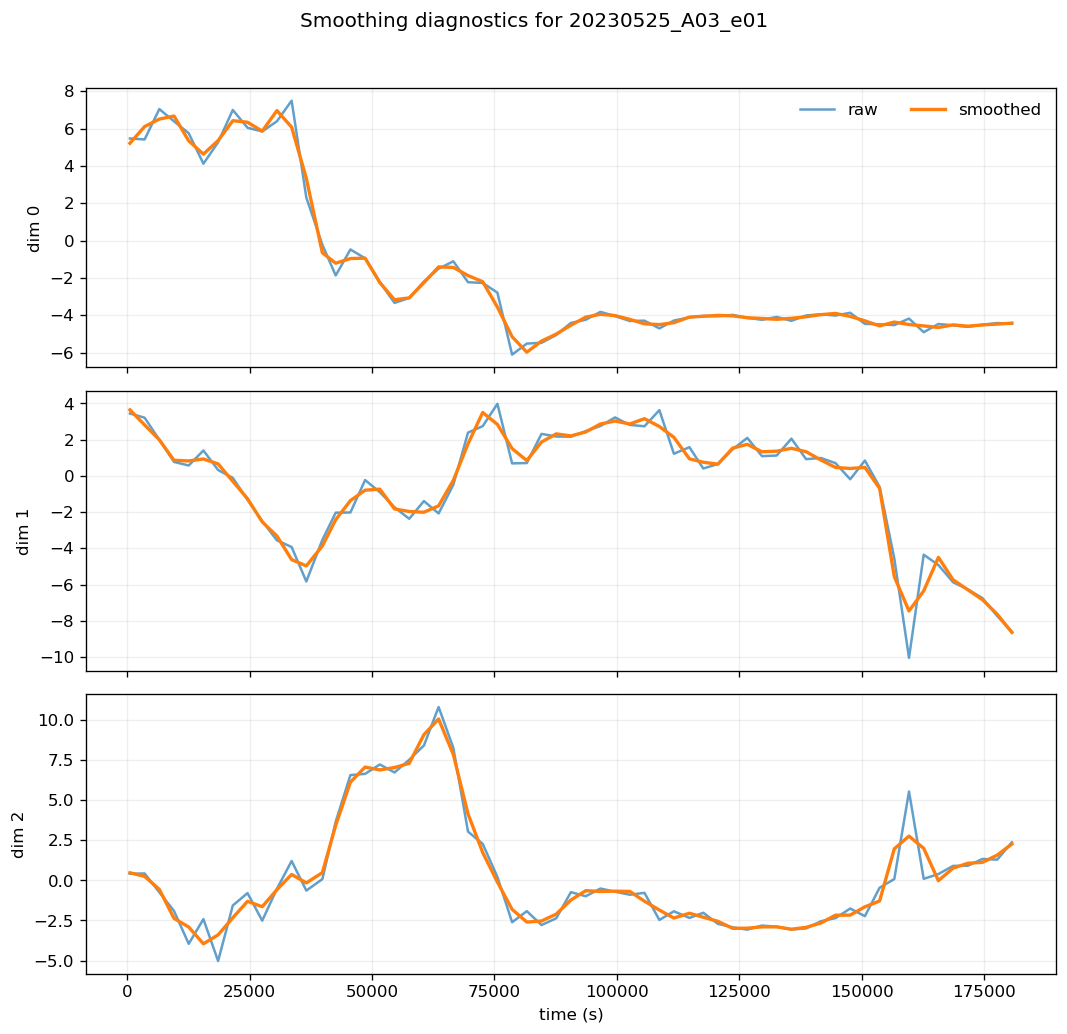

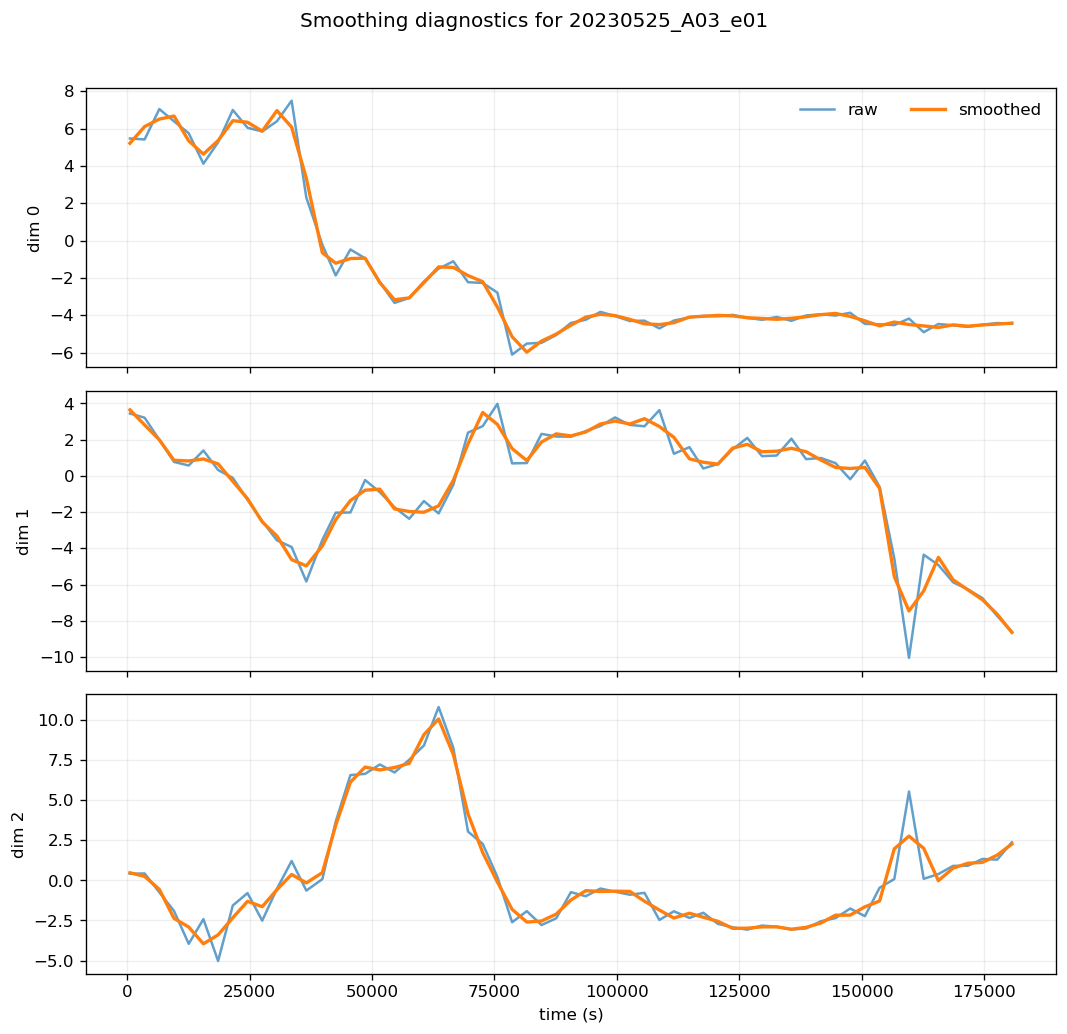

In [6]:
plot_raw_vs_smoothed_timeseries(smoothed_example)


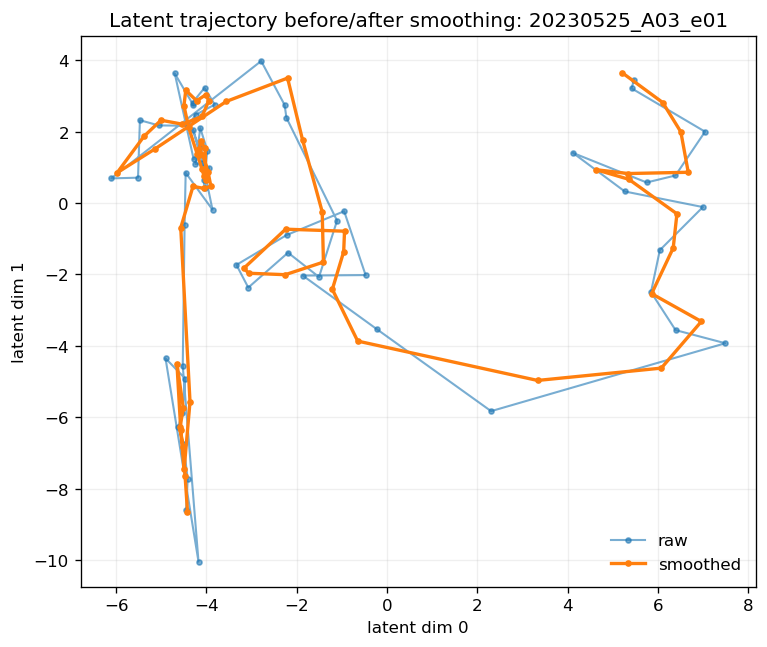

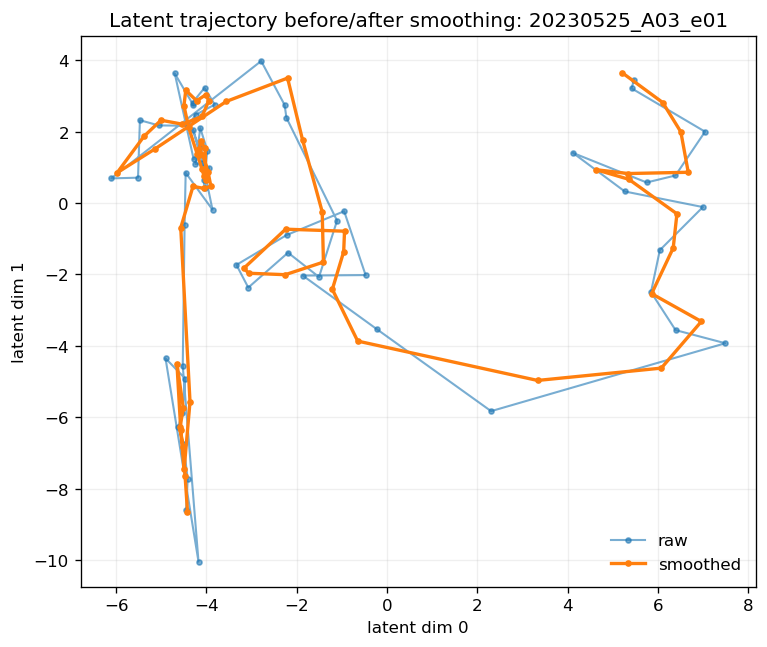

In [7]:
plot_latent_trajectory_before_after_smoothing(smoothed_example)


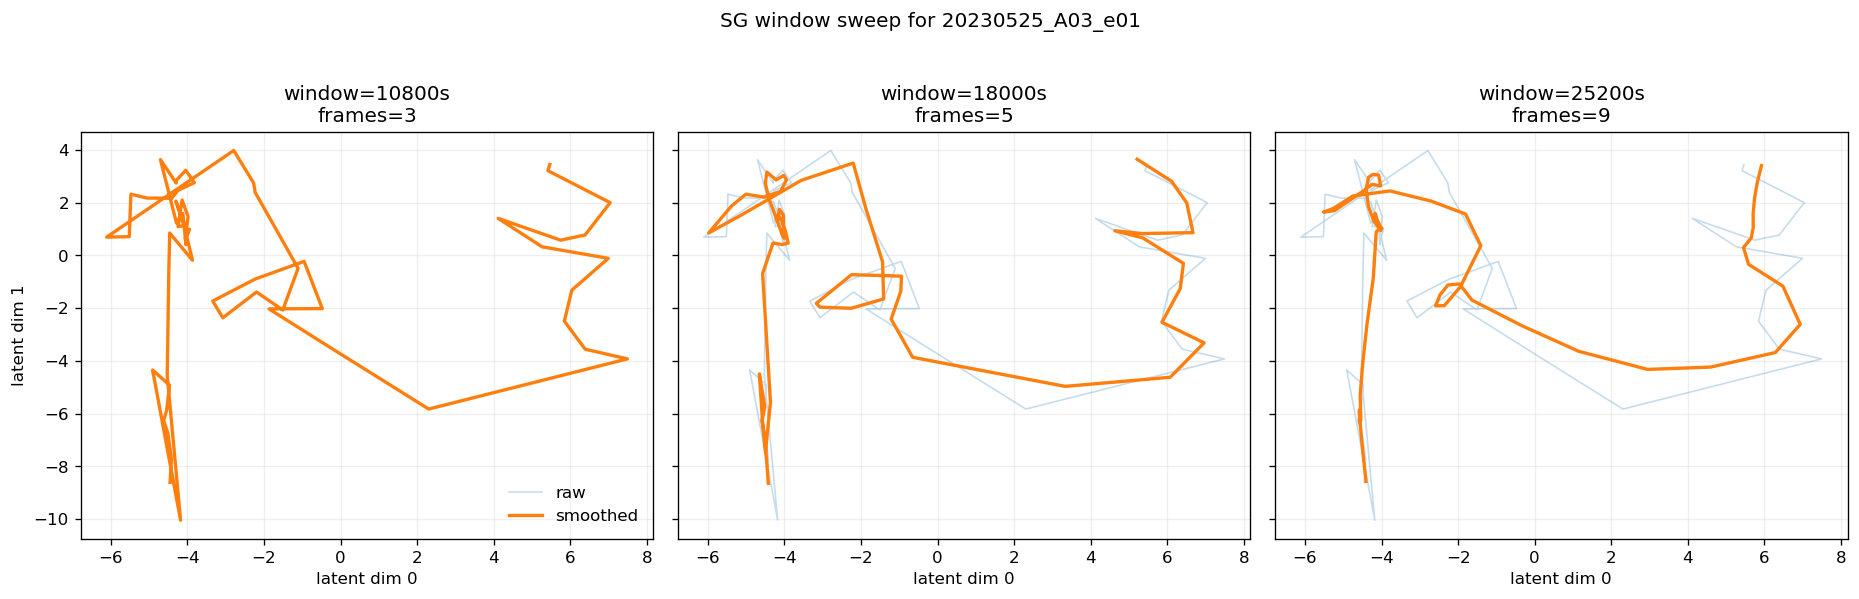

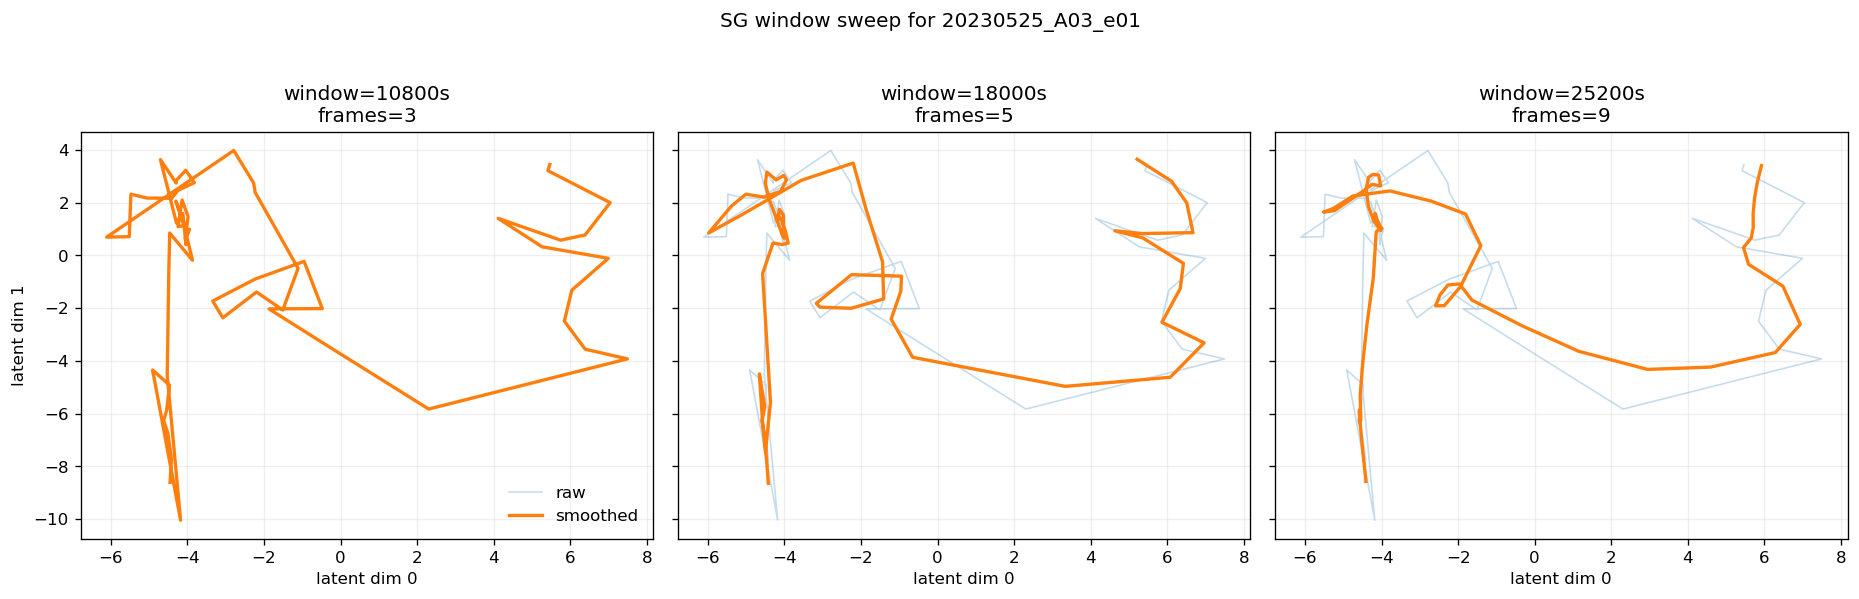

In [8]:
plot_sg_parameter_sweep(example, window_seconds_values=[3.0 * 3600.0, 5.0 * 3600.0, 7.0 * 3600.0])

## Batch Smoothing QC

Smooth the notebook subset and summarize how the chosen time window translates into frame windows across real trajectories.


In [9]:
smoothed_subset = smooth_trajectories(selected_trajectories, window_seconds=window_seconds, poly_order=poly_order)
pd.DataFrame(
    {
        "embryo_id": [traj.source.embryo_id for traj in smoothed_subset],
        "window_frames": [traj.window_frames for traj in smoothed_subset],
        "delta_t": [traj.source.delta_t for traj in smoothed_subset],
        "n_segments": [traj.diagnostics.get("n_segments", np.nan) for traj in smoothed_subset],
        "n_hard_gaps": [traj.diagnostics.get("n_hard_gaps", np.nan) for traj in smoothed_subset],
    }
).head(10)


,embryo_id,window_frames,delta_t,n_segments,n_hard_gaps
0,20230525_A03_e01,5,3000.3508,1,0
1,20230525_A04_e02,5,3000.3508,1,0
2,20230525_A05_e01,5,3000.3508,1,0
3,20230525_A06_e01,5,3000.3508,1,0
4,20230525_A07_e01,5,3000.3508,1,0
5,20230525_A09_e01,5,3000.3508,1,0
6,20230525_A11_e01,5,3000.3508,1,0
7,20230525_A12_e01,5,3000.3508,1,0


## QC Questions

- Are any trajectories getting extremely short or extremely long SG frame windows?
- Do hard-gap-heavy embryos need separate filtering before prediction?
- Does changing `window_seconds` visibly alter the latent geometry in a way that looks implausible?
